# **Overview of this toolkit**

##### The purpose of this toolkit is to support users in creating standardised, modular workflows when working with the Bonsai ecosystem. Building on <code>harp-python</code> plus the Harp YAML schemas (e.g., `device.yml`, `soundcard.yml`), it provides higher-level utilities for extracting data exported from Bonsai experiment directories to build consistent, readable data structures for analysis.


### The core features of this toolkit include:

 1) Automate data extraction from Bonsai experiment directories and converting <code>.bin</code> files into a common <code>movement</code>-ready readable format (<code>xarrays</code> or <code>dataframes</code>)
 2) Process data from multiple peripherals and registers into convenient unified dataframes
 3) Provide utilities for handling other data formats present in Bonsai Workflows
 4) Enable the alignment of multiple different data acquistion sources 


# **Toolkit Modules**

#### 1) HarpExtender

#### 2) Timestamps

#### 3) LookupArrays

#### 4) Validators

#### 5) Filetypes

#### 6) Devices

#### 7) MultiDevices

#### 8) Alignment

-------------

# **The Problem:**

## 1.1| Harp-Python's Built-In Tools

Whilst the harp-python API provides users with access with access to a set of basic functions to access harp device data in Python, users will often find themselves needing to write custom code to handle common tasks, requiring significant manual user input. 

To show how this toolkit can be used, we will first demonstrate the general workflow for accessing harp device data using harp-python's built-in tools.

### **<code>Harp-python</code>'s Built-In Approach**

When working with Harp devices, users will find that their experimental data is organised into a hierarchical folder structure, with each device having its own subfolder containing multiple .bin files corresponding to different registers. 
Furthermore, the naming conventions for these .bin files possess a consistent pattern of <code>DeviceName_RegisterAddress_Timestamp.bin</code>, where:
- <code>DeviceName</code> is the name of the device (e.g. Behavior1)
- <code>RegisterAddress</code> is the address of the register (e.g. 32)
- <code>Timestamp</code> indicates when the data recording started (e.g. 1904-01-01T02-00-00)


##### Reading data from these .bin files using harp-python typically involves the following steps:
1. **Create a Device Reader object**: Instantiate a device reader object using <code>harp.create_reader(***device_yaml_path***)</code>, where <code>device_yaml_path</code> is the path to the YAML file for that specific type of harp device.
2. **Manually Find the Register Name Corresponding to the Register Address**: Since harp-python requires users to specify register names (not addresses) when reading data, users must manually look up the register name corresponding to the register address they wish to read. This information can be found in the device's YAML file or documentation.
3. **Read the Data from the .bin File**: Use the device reader object to read the data from the .bin file using <code>reader.{*register_name*}.read({*file_path*})</code>, where <code>register_name</code> is the name of the register obtained in step 2, and <code>file_path</code> is the path to the .bin file.</code>

### **Example:**

In [2]:
#======== Setup 
import harp

device_yaml_path= './device.yml'
device_register_path= './Bonsai_logs/2025-08-21T12-18-51/Behavior1/Behavior1_32_1904-01-01T02-00-00.bin'


#### Create Harp Reader

In [3]:
#======= Create Device Object
reader= harp.create_reader(device_yaml_path)

#### Find Register Name Corresponding to Register Address of Interest

- Users must manually check which register name corresponds to the register address of interest. This can be done by inspecting the device schema .yml file. 

#### Accessing Data from a Single Register

- For example, the Harp Behaviour board records nosepoke device activations under Register 32, with register name <code>DigitalInputState</code>: 

In [4]:
#======== Load Device Schema and Register Data
reader.DigitalInputState.read(device_register_path)

,DIPort0,DIPort1,DIPort2,DI3
Time,,,,
9827.105376,False,False,True,False
9827.388576,False,False,False,False


### **The Problem:**

Whilst these tools provide a basic framework for accessing harp device data, users will often find themselves working with experiment logs containing multiple devices and multiple registers per device, as well as needing to collate data across sessions, devices, and device types. Using the above approach, users will need to manually repeat the above steps for each register of interest across multiple devices and sessions, which can be time-consuming and error-prone.

### **The Solution:**

This toolkit extends harp-python's built-in tools by providing a set of modular functions that automate many of the repetitive tasks involved in accessing and structuring harp device data. Key features of this toolkit include:

- **Automated Register Name Lookup**: Functions that automatically map register addresses to register names, eliminating the need for manual lookups.
- **Batch Data Extraction**: Utilities that allow users to extract data from multiple registers and devices in a single function call.
- **Formatting and Restructuring Data**: Functions that allow users to take dataframes extracted from individual registers and collate parts of or the whole dataframe from one or more devices into a single, unified dataframe for easier analysis.



We can take advantage of the consistent naming conventions of Bonsai experimental directorires and harp-python's low-level data access functions to create a set of modular functions that automate the process of extracting, structuring, and manipulating harp device data.

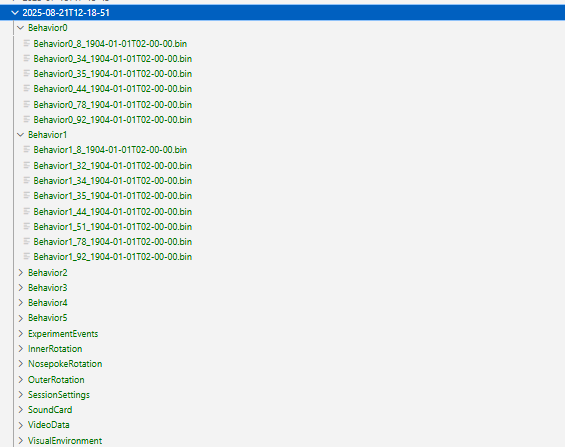